# Crabs data visualization

### Import libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
crabs_data = pd.read_csv("crabs.csv")
crabs_data.head()

,sp,sex,index,FL,RW,CL,CW,BD
0,B,M,1,8.1,6.7,16.1,19.0,7.0
1,B,M,2,8.8,7.7,18.1,20.8,7.4
2,B,M,3,9.2,7.8,19.0,22.4,7.7
3,B,M,4,9.6,7.9,20.1,23.1,8.2
4,B,M,5,9.8,8.0,20.3,23.0,8.2


In [3]:
crabs_data = crabs_data.rename(columns = {"sp":"species", "FL": "frontal_lobe", "RW": "rear_width", "CL": "carapace_midline", "CW": "carapace_width_max", "BD": "body_depth"})
crabs_data["species"] = crabs_data["species"].map({"B":"Blue", "O": "Orange"})
crabs_data["sex"] = crabs_data["sex"].map({"F":"Female", "M": "Male"})


In [4]:
crabs_data.tail()

,species,sex,index,frontal_lobe,rear_width,carapace_midline,carapace_width_max,body_depth
195,Orange,Female,46,21.4,18.0,41.2,46.2,18.7
196,Orange,Female,47,21.7,17.1,41.7,47.2,19.6
197,Orange,Female,48,21.9,17.2,42.6,47.4,19.5
198,Orange,Female,49,22.5,17.2,43.0,48.7,19.8
199,Orange,Female,50,23.1,20.2,46.2,52.5,21.1


The goal is to separate the 200 crabs into four classes, given by the 2x2 configurations for sex (male/female) and species (blue/orange).

In [6]:
crabs_data['class'] = crabs_data.species + crabs_data.sex

crabs_data['class'].value_counts()

class
BlueMale        50
BlueFemale      50
OrangeMale      50
OrangeFemale    50
Name: count, dtype: int64

We'll start with a basic exploration of the data set.

In [10]:

data_columns = ['frontal_lobe','rear_width','carapace_midline','carapace_width_max','body_depth']
crabs_data[data_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
frontal_lobe,200.0,15.5830,3.495325,7.2,12.900,15.55,18.050,23.1
rear_width,200.0,12.7385,2.573340,6.5,11.000,12.80,14.300,20.2
carapace_midline,200.0,32.1055,7.118983,14.7,27.275,32.10,37.225,47.6
carapace_width_max,200.0,36.4145,7.871955,17.1,31.500,36.80,42.000,54.6
body_depth,200.0,14.0305,3.424772,6.1,11.400,13.90,16.600,21.6


Boxplot of the relevant features.


<Axes: >

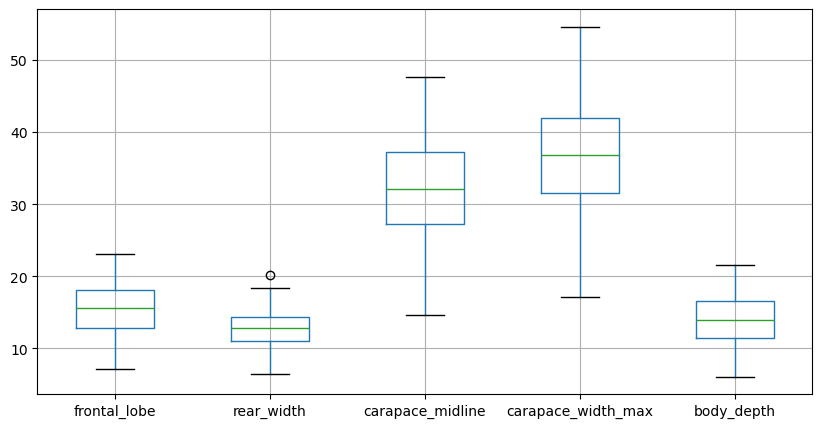

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
crabs_data[data_columns].boxplot()

### Initial Visualization of the Classes

<Axes: title={'center': 'frontal_lobe'}, xlabel='class'>

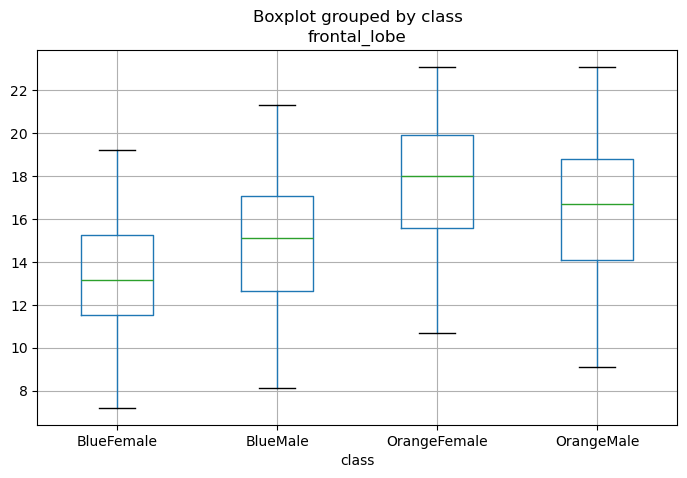

In [13]:
crabs_data.boxplot(column='frontal_lobe', by = 'class', figsize=(8,5))

<Axes: title={'center': 'rear_width'}, xlabel='class'>

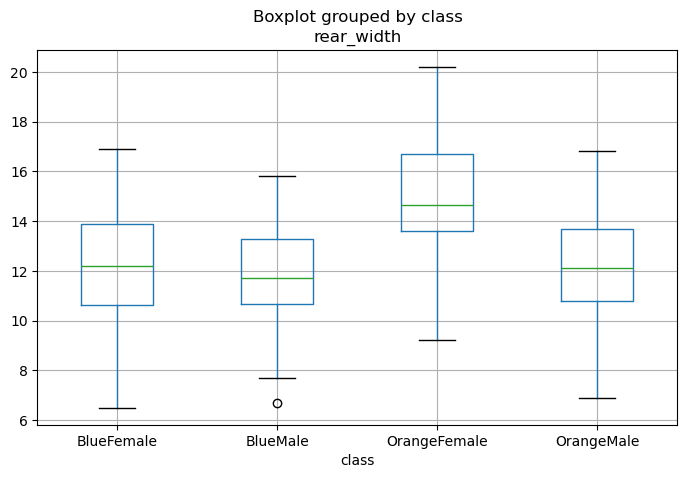

In [14]:
crabs_data.boxplot(column='rear_width', by = 'class', figsize=(8,5))

<Axes: title={'center': 'carapace_midline'}, xlabel='class'>

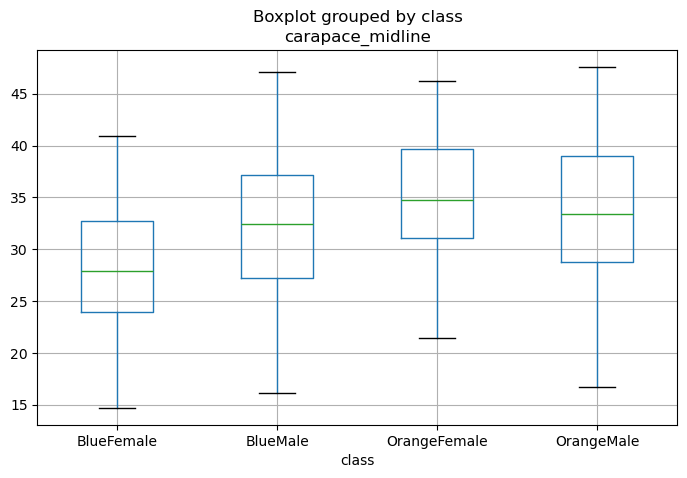

In [15]:
crabs_data.boxplot(column='carapace_midline', by = 'class', figsize=(8,5))

<Axes: title={'center': 'carapace_width_max'}, xlabel='class'>

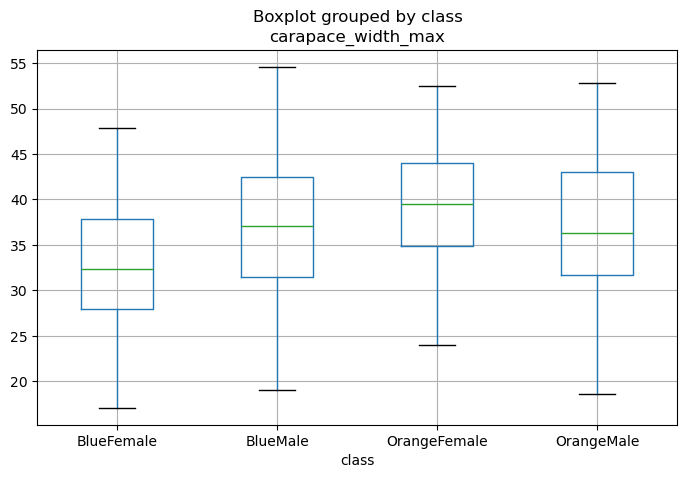

In [21]:
crabs_data.boxplot(column='carapace_width_max', by = 'class', figsize=(8,5))

<Axes: title={'center': 'body_depth'}, xlabel='class'>

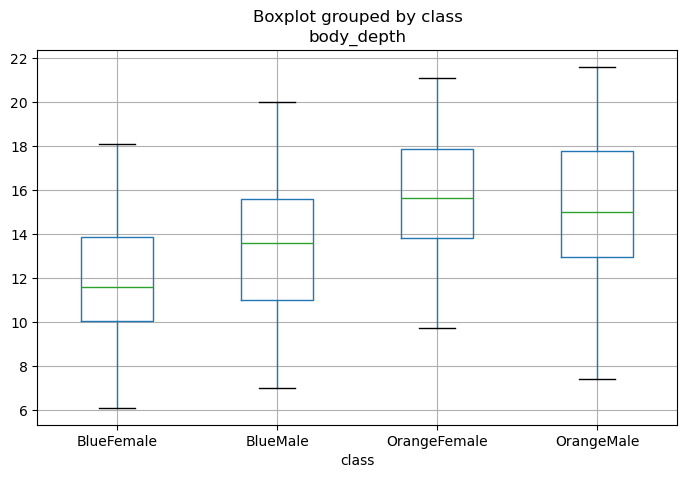

In [16]:
crabs_data.boxplot(column='body_depth', by = 'class', figsize=(8,5))

Visualization through Histograms

array([[<Axes: title={'center': 'frontal_lobe'}>,
        <Axes: title={'center': 'rear_width'}>,
        <Axes: title={'center': 'carapace_midline'}>,
        <Axes: title={'center': 'carapace_width_max'}>,
        <Axes: title={'center': 'body_depth'}>, <Axes: >]], dtype=object)

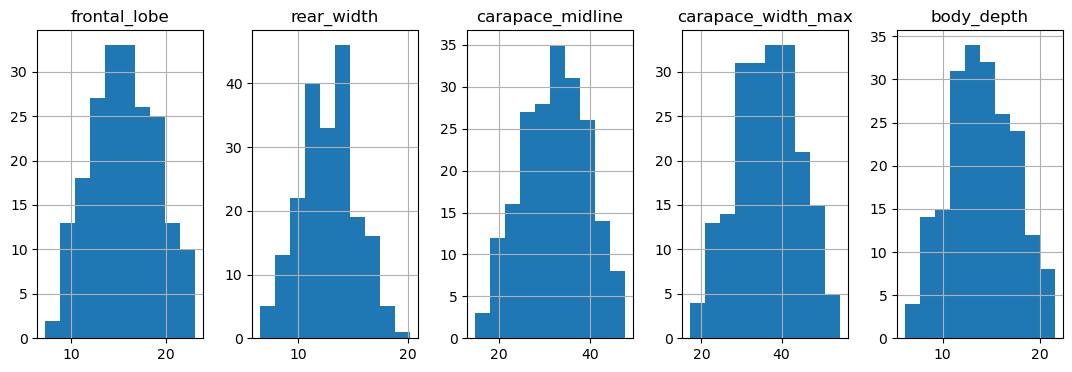

In [17]:
crabs_data[data_columns].hist(figsize=(16,4),layout=(1,6)) # layout = Tuple of (rows, columns) the histograms

<Axes: xlabel='frontal_lobe', ylabel='Count'>

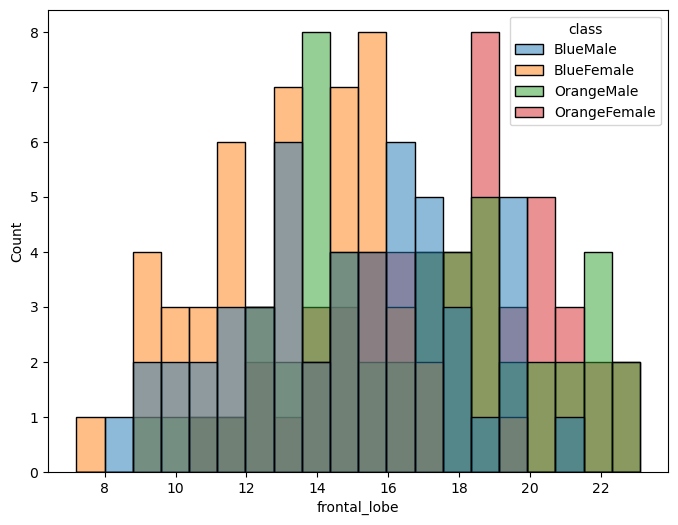

In [18]:
plt.figure(figsize=(8,6))
sns.histplot(crabs_data,x='frontal_lobe',hue='class',bins=20)

<Axes: xlabel='rear_width', ylabel='Count'>

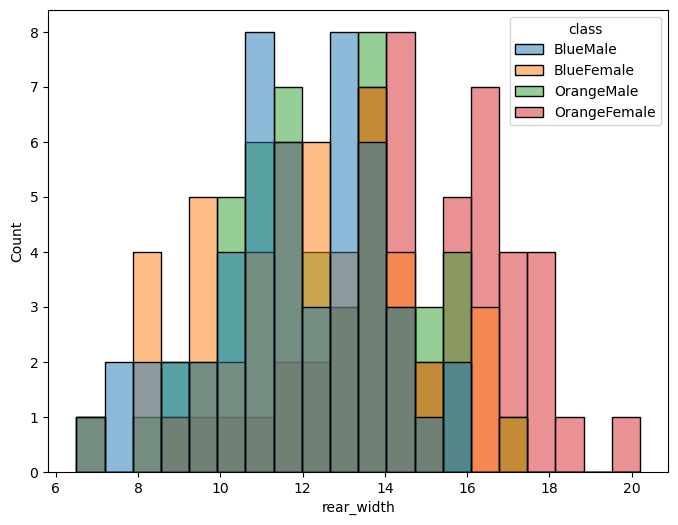

In [19]:
plt.figure(figsize=(8,6))
sns.histplot(crabs_data,x='rear_width',hue='class',bins=20)

<Axes: xlabel='carapace_midline', ylabel='Count'>

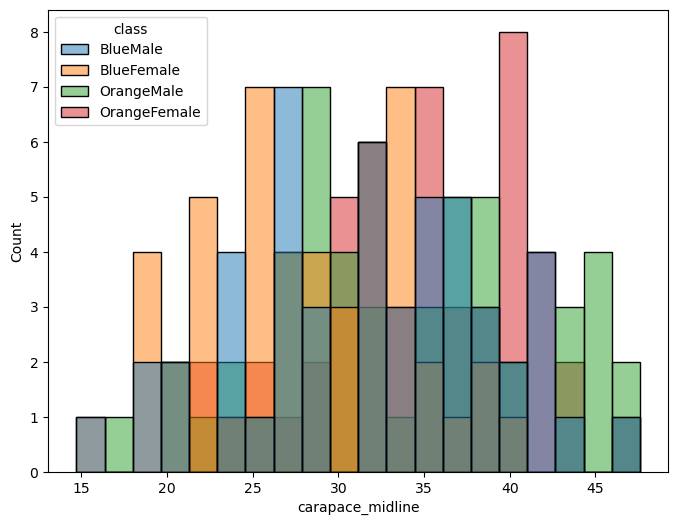

In [20]:
plt.figure(figsize=(8,6))
sns.histplot(crabs_data,x='carapace_midline',hue='class',bins=20)

<Axes: xlabel='carapace_width_max', ylabel='Count'>

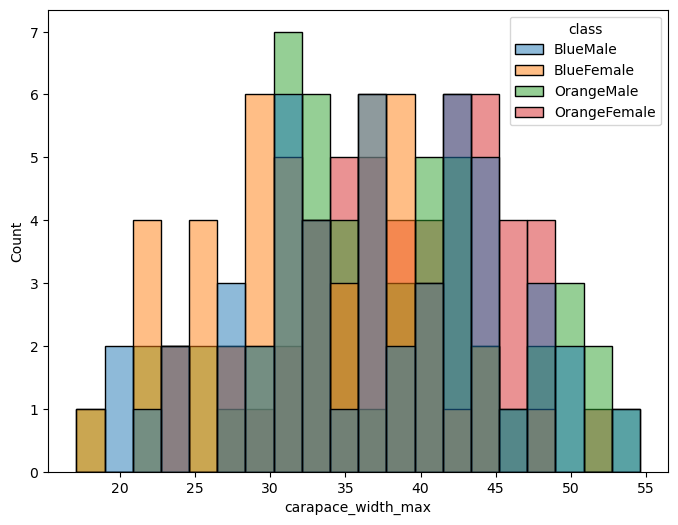

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(crabs_data,x='carapace_width_max',hue='class',bins=20)

<Axes: xlabel='body_depth', ylabel='Count'>

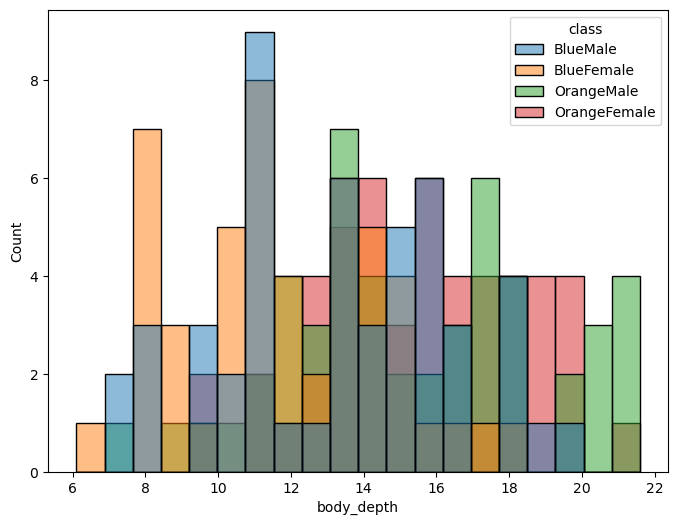

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(crabs_data,x='body_depth',hue='class',bins=20)

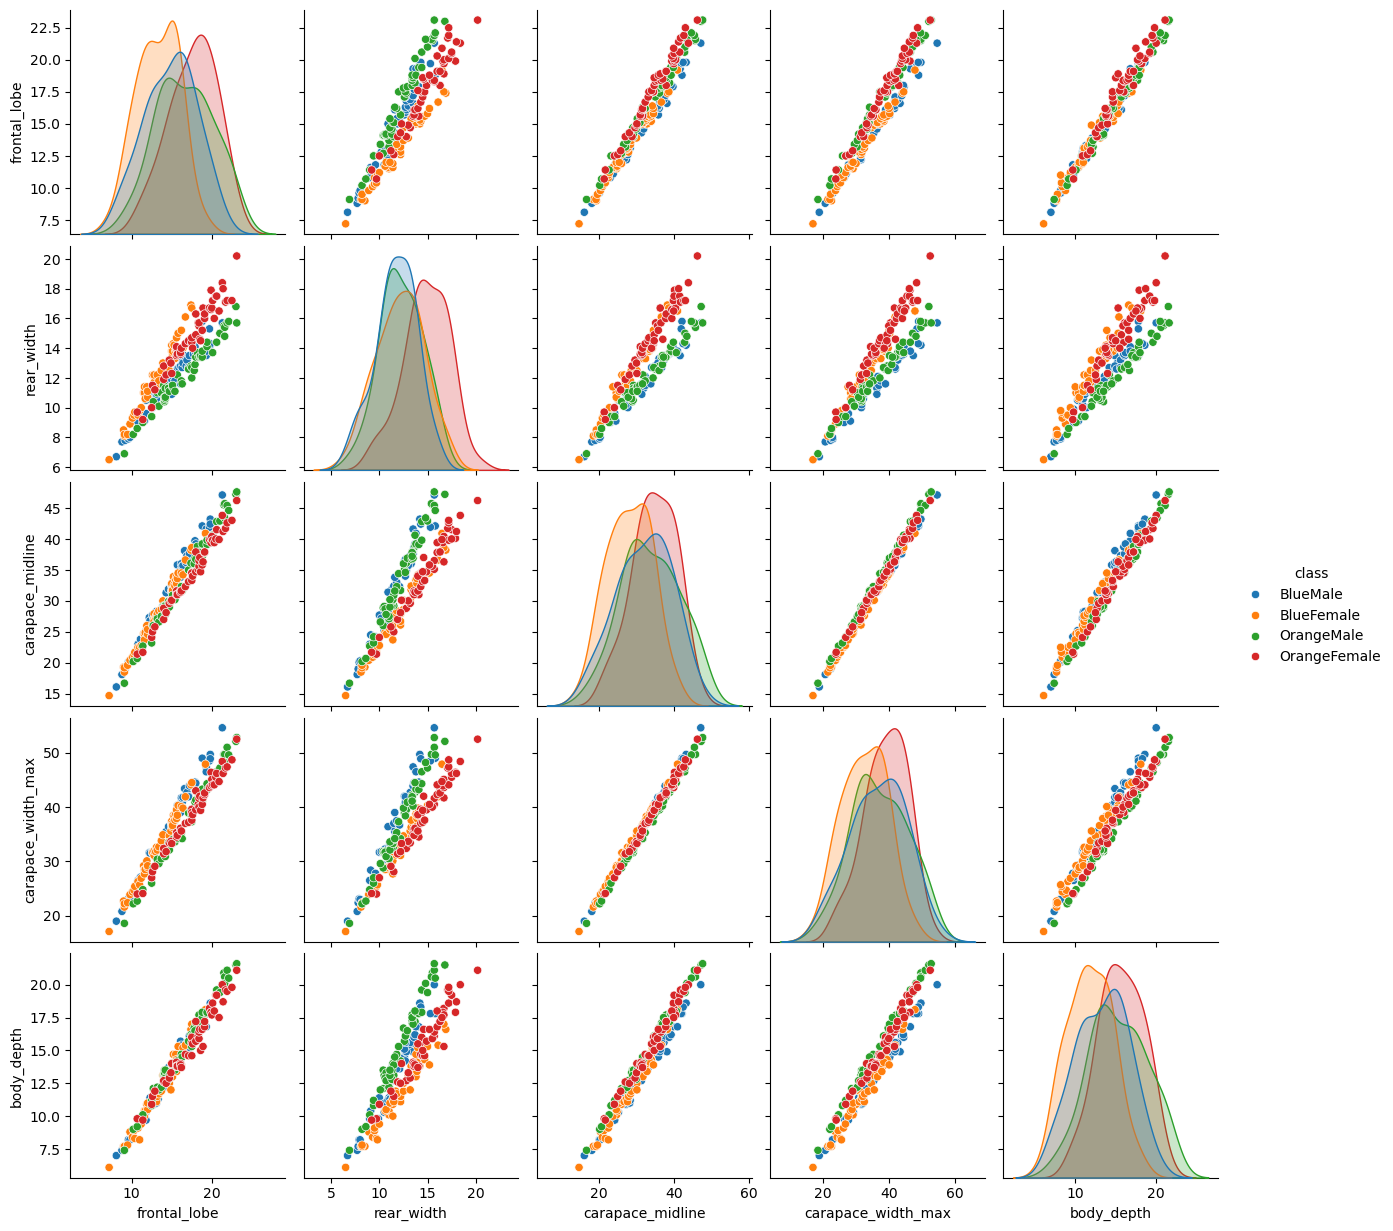

In [28]:
sns.pairplot(crabs_data, vars=data_columns, hue='class')

### Purpose of using PCA
The high dimensionality of the data makes it difficult to manage and understand it.

Dimensionality reduction methods allow
 

*   Reduce unnecessary dimensions/noise
*   Reduce the computational cost of learning
*   Visualize data in 2D/3D